In [1]:
from sklearn.base import clone
from itertools import combinations
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

#### **Data import and preprocessing**

Class labels [1 2 3]
   Class label  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0            1    14.23        1.71  2.43               15.6        127   
1            1    13.20        1.78  2.14               11.2        100   
2            1    13.16        2.36  2.67               18.6        101   
3            1    14.37        1.95  2.50               16.8        113   
4            1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline  
0             5.64  1.04           

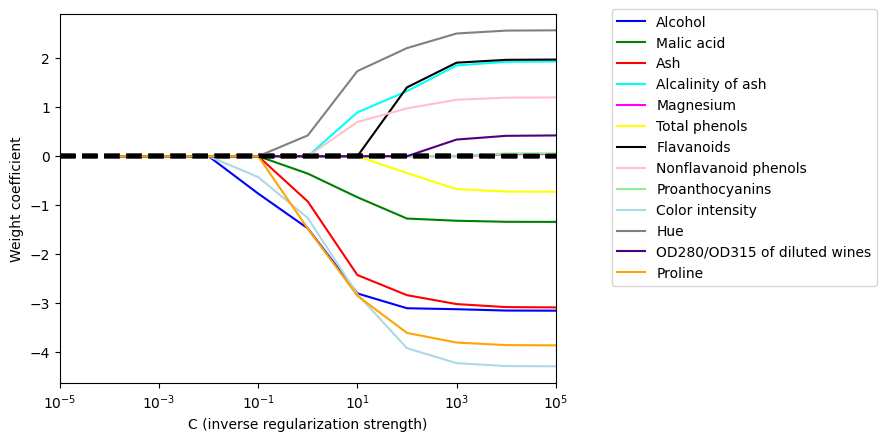

In [2]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)
df_wine.columns = ['Class label', 'Alcohol','Malic acid', 'Ash','Alcalinity of ash', 'Magnesium','Total phenols', 'Flavanoids',
                   'Nonflavanoid phenols','Proanthocyanins','Color intensity', 'Hue','OD280/OD315 of diluted wines','Proline']

print('Class labels', np.unique(df_wine['Class label']))
print(df_wine.head())

X = df_wine.iloc[:, 1:].values
y = df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

######################################################### Feature Scaling
# 1. Feature Normalization (chaging the range from 0-1)
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm = mms.transform(X_test)

# 2. Feature Standardization (centre around mean=0 and std=1)
from sklearn.preprocessing import StandardScaler

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

######################################################## Regularization
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(l1_ratio=1, C=1.0, solver='saga', max_iter=5000)
lr.fit(X_train_std, y_train)
print('Training accuracy:', lr.score(X_train_std, y_train))
print('Test accuracy:', lr.score(X_test_std, y_test))

import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.subplot(111)
colors = ['blue', 'green', 'red', 'cyan','magenta', 'yellow', 'black','pink', 'lightgreen', 'lightblue','gray', 'indigo', 'orange']
weights, params = [], []

for c in np.arange(-4., 6.):
    lr = LogisticRegression(l1_ratio=1, C=10.**c,solver='saga', max_iter=5000, random_state=0)
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10**c)

weights = np.array(weights)
for column, color in zip(range(weights.shape[1]), colors):
    plt.plot(params, weights[:, column],label=df_wine.columns[column + 1],color=color)
    plt.axhline(0, color='black', linestyle='--', linewidth=3)
    plt.xlim([10**(-5), 10**5])
    plt.ylabel('Weight coefficient')
    plt.xlabel('C (inverse regularization strength)')
    plt.xscale('log')
    plt.legend(loc='upper left')
    ax.legend(loc='upper center',bbox_to_anchor=(1.38, 1.03),ncol=1, fancybox=True)

plt.show()

#### **SBS Algorithm (for feature selection) Implementation**

In [18]:
################################################ Feature Selection

# 1. SBS Algorithm - sequential backward selection
class SBS:
    def __init__(self, estimator, k_features, score=accuracy_score, test_size=0.25, random_state=1):
        self.estimator = clone(estimator)
        self.score = score
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=self.random_state, test_size=self.test_size)

        curr_dim = X.shape[1]
        self.indices_ = list(range(curr_dim))
        self.subset_ = [self.indices_]
        self.scores_ = [self._calc_score(X_train, y_train, X_test, y_test, self.indices_)]

        while (curr_dim > self.k_features):
            temp_score = -1
            temp_indexlist = self.indices_

            for p in combinations(self.indices_, r = curr_dim-1):
                p_score = self._calc_score(X_train, y_train, X_test, y_test, p)

                if(p_score > temp_score):
                    temp_score = p_score
                    temp_indexlist = p
            
            curr_dim -= 1
            self.indices_ = temp_indexlist
            self.subset_.append(temp_indexlist)
            self.scores_.append(temp_score)
        
        self.best_score_ = self.scores_[-1]
        return self


    def transform(self, X):
        return X[:, self.indices_]
    
    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:,indices])
        score = self.score(y_test, y_pred)
        
        return score

Training Accuracy :  0.967741935483871
Testing Accuracy :  0.9629629629629629


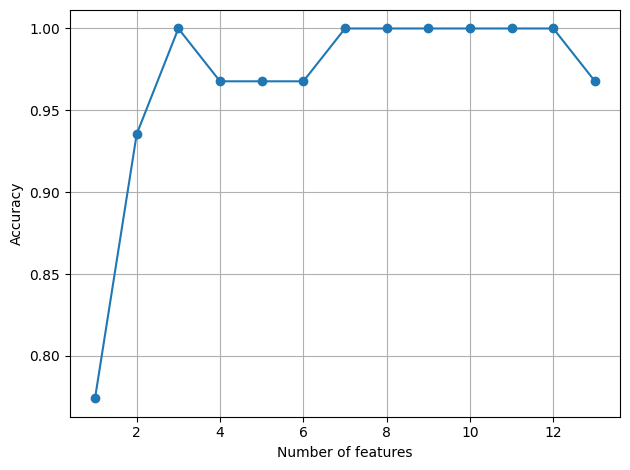

Index(['Alcohol', 'Malic acid', 'OD280/OD315 of diluted wines'], dtype='object')
Training Accuracy :  0.9516129032258065
Testing Accuracy :  0.9259259259259259


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

# Checking the accuracy of knn without any feature reduction
knn.fit(X_train_std, y_train)
print("Training Accuracy : ", knn.score(X_train_std, y_train))
print("Testing Accuracy : ", knn.score(X_test_std, y_test))

# Checking the SBS effect and accuracy on knn
sbs = SBS(estimator=knn, k_features=1)
sbs.fit(X_train_std, y_train)

k_feat = [len(k) for k in sbs.subset_]
plt.plot(k_feat, sbs.scores_, marker='o')
plt.ylabel('Accuracy')
plt.xlabel('Number of features')
plt.grid()
plt.tight_layout()
plt.show()

# Checking the best accuracy results
kx = list(sbs.subset_[10])
print(df_wine.columns[1:][kx])

knn.fit(X_train_std[:, kx], y_train)
print("Training Accuracy : ", knn.score(X_train_std[:, kx], y_train))
print("Testing Accuracy : ", knn.score(X_test_std[:, kx], y_test))



#### **Random Forest (for feature selection) Implementation**

 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872
 8) Magnesium                      0.031357
 9) Malic acid                     0.025648
10) Proanthocyanins                0.025570
11) Alcalinity of ash              0.022366
12) Nonflavanoid phenols           0.013354
13) Ash                            0.013279


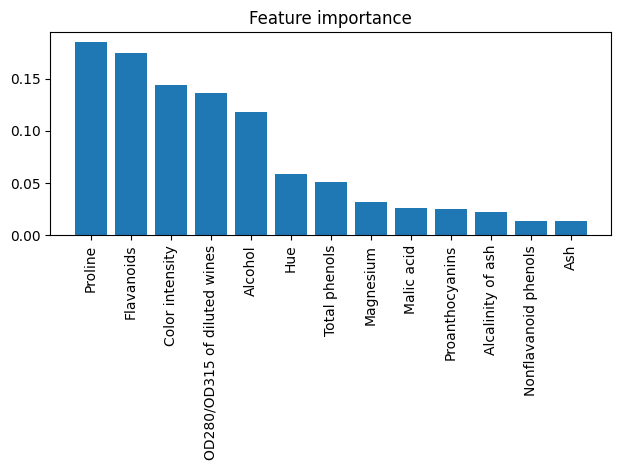

In [19]:
# 2. Random Forest can be used for feature selection as we can get feature importance from it
from sklearn.ensemble import RandomForestClassifier

feat_labels = df_wine.columns[1:]
forest = RandomForestClassifier(n_estimators=500,random_state=1)

forest.fit(X_train, y_train)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30,feat_labels[indices[f]],importances[indices[f]]))

plt.title('Feature importance')
plt.bar(range(X_train.shape[1]),importances[indices],align='center')
plt.xticks(range(X_train.shape[1]),feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()


In [ ]:
# in sklearn we have the option to set the threshold for selecting the features
from sklearn.feature_selection import SelectFromModel
sfm = SelectFromModel(forest, threshold=0.1, prefit=True)

X_selected = sfm.transform(X_train)
print('Number of features that meet this threshold','criterion:', X_selected.shape[1])

for f in range(X_selected.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30,feat_labels[indices[f]],importances[indices[f]]))

Number of features that meet this threshold criterion: 5
 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
